<a href="https://colab.research.google.com/github/Shruthiganji7/Data-library/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

This project focuses on analyzing and visualizing a Student Performance dataset using Python libraries such as Pandas, Matplotlib, and Seaborn in Google Colab. The main objective of the project is to perform data preprocessing, explore student academic performance, and generate meaningful insights through visualizations and dashboards.

The project includes tasks such as checking for missing values, detecting duplicate records, identifying outliers, and creating visual reports to understand patterns affecting student performance. Through this analysis, important factors like study hours, attendance, parental education, and subject-wise scores are examined to better understand student achievement trends.


**Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Student_Performance_Dataset.csv to Student_Performance_Dataset.csv


**Load Dataset**

In [3]:
df = pd.read_csv("Student_Performance_Dataset.csv")

**View First Rows**

In [4]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

**Statistical Summary**

In [6]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


**Handle Missing Values**

**Check Missing Values**

In [7]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Class,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Parental_Education,0
Internet_Access,0
Extracurricular_Activities,0
Math_Score,0


## **Missing Value Analysis**

The dataset was checked for missing values using the `isnull().sum()` function.

Result:
- No missing values were found in any column.
- The dataset was already complete and clean.

**Handle Duplicates**

**Check Duplicate Rows**

In [9]:
df.duplicated().sum()

np.int64(0)

**Duplicate Value Analysis**

The dataset was checked for duplicate records using the `duplicated().sum()` function.

Result:
- No duplicate rows were found in the dataset.
- The dataset maintained data consistency and uniqueness.

**Handle Outliers**

**Detect Outliers**

**Boxplot**

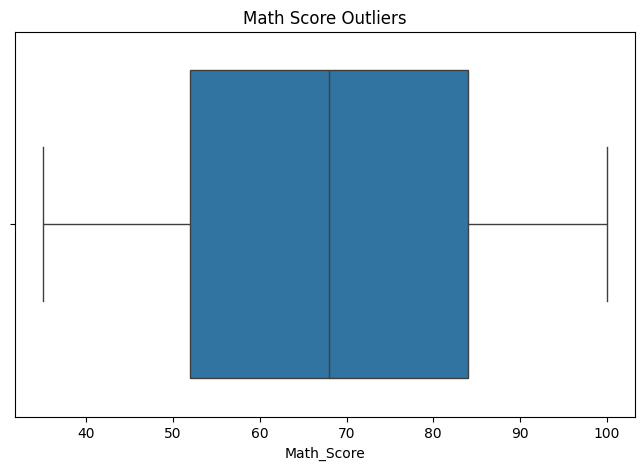

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Math_Score'])

plt.title("Math Score Outliers")

plt.show()

**Remove Outliers Using IQR Method**

In [15]:
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['Math_Score'] >= lower_limit) &
    (df['Math_Score'] <= upper_limit)
]


Outliers were detected using boxplots and removed using the Interquartile Range (IQR) method.

**Data Visualization**

**Gender Distribution**

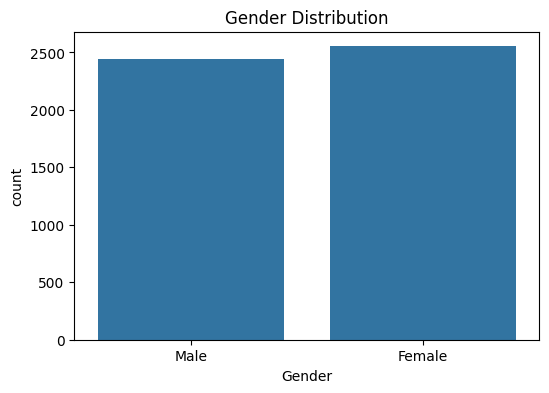

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

**Average Subject Scores**

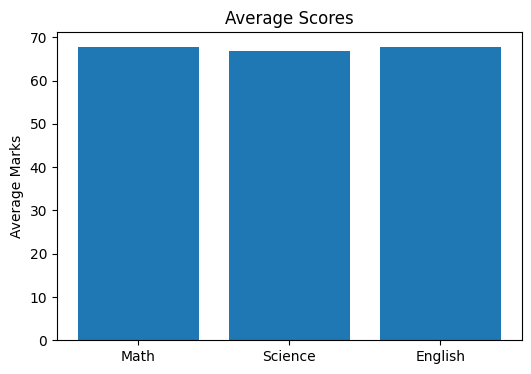

In [18]:
scores = [
    df['Math_Score'].mean(),
    df['Science_Score'].mean(),
    df['English_Score'].mean()
]

subjects = ['Math', 'Science', 'English']

plt.figure(figsize=(6,4))

plt.bar(subjects, scores)

plt.title("Average Scores")

plt.ylabel("Average Marks")

plt.show()

**Correlation Heatmap**

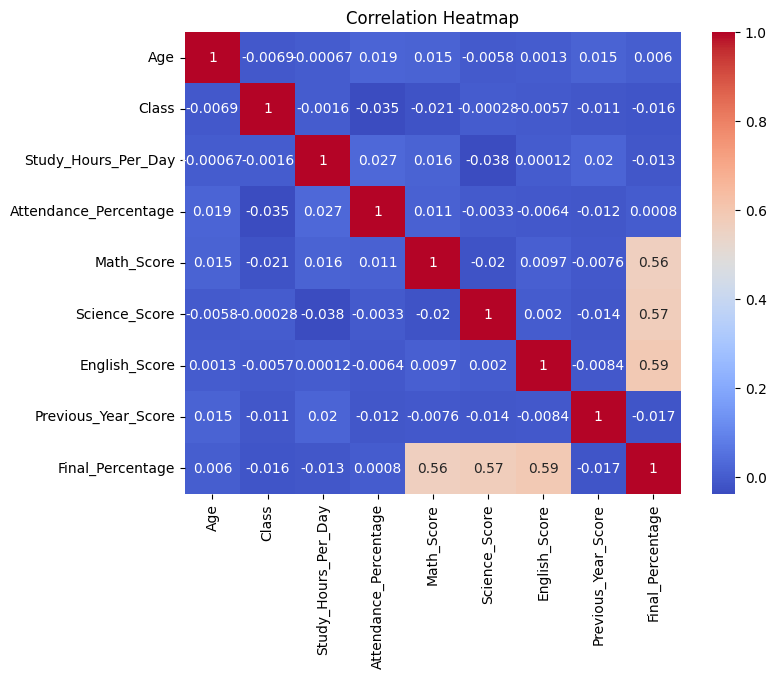

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Study Hours vs Performance**

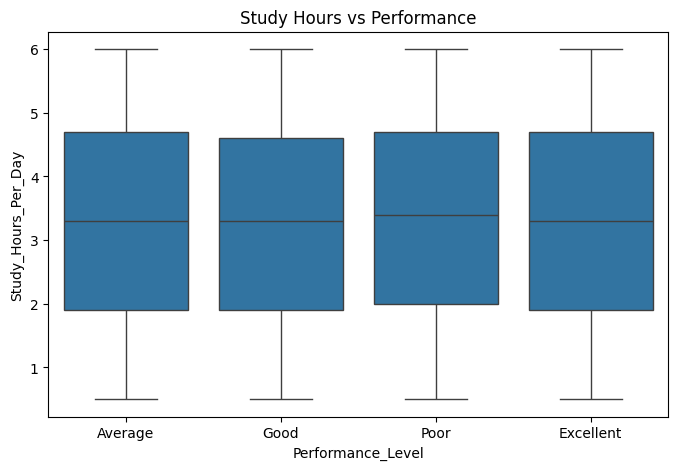

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Performance_Level',
    y='Study_Hours_Per_Day',
    data=df
)

plt.title("Study Hours vs Performance")

plt.show()

**Parent Education vs Final Percentage**

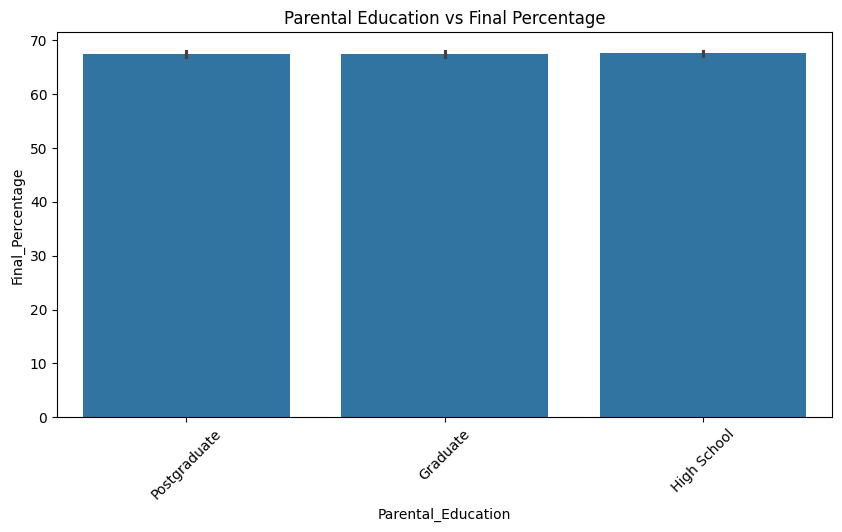

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Parental_Education',
    y='Final_Percentage',
    data=df
)

plt.xticks(rotation=45)

plt.title("Parental Education vs Final Percentage")

plt.show()

**Dashboard**

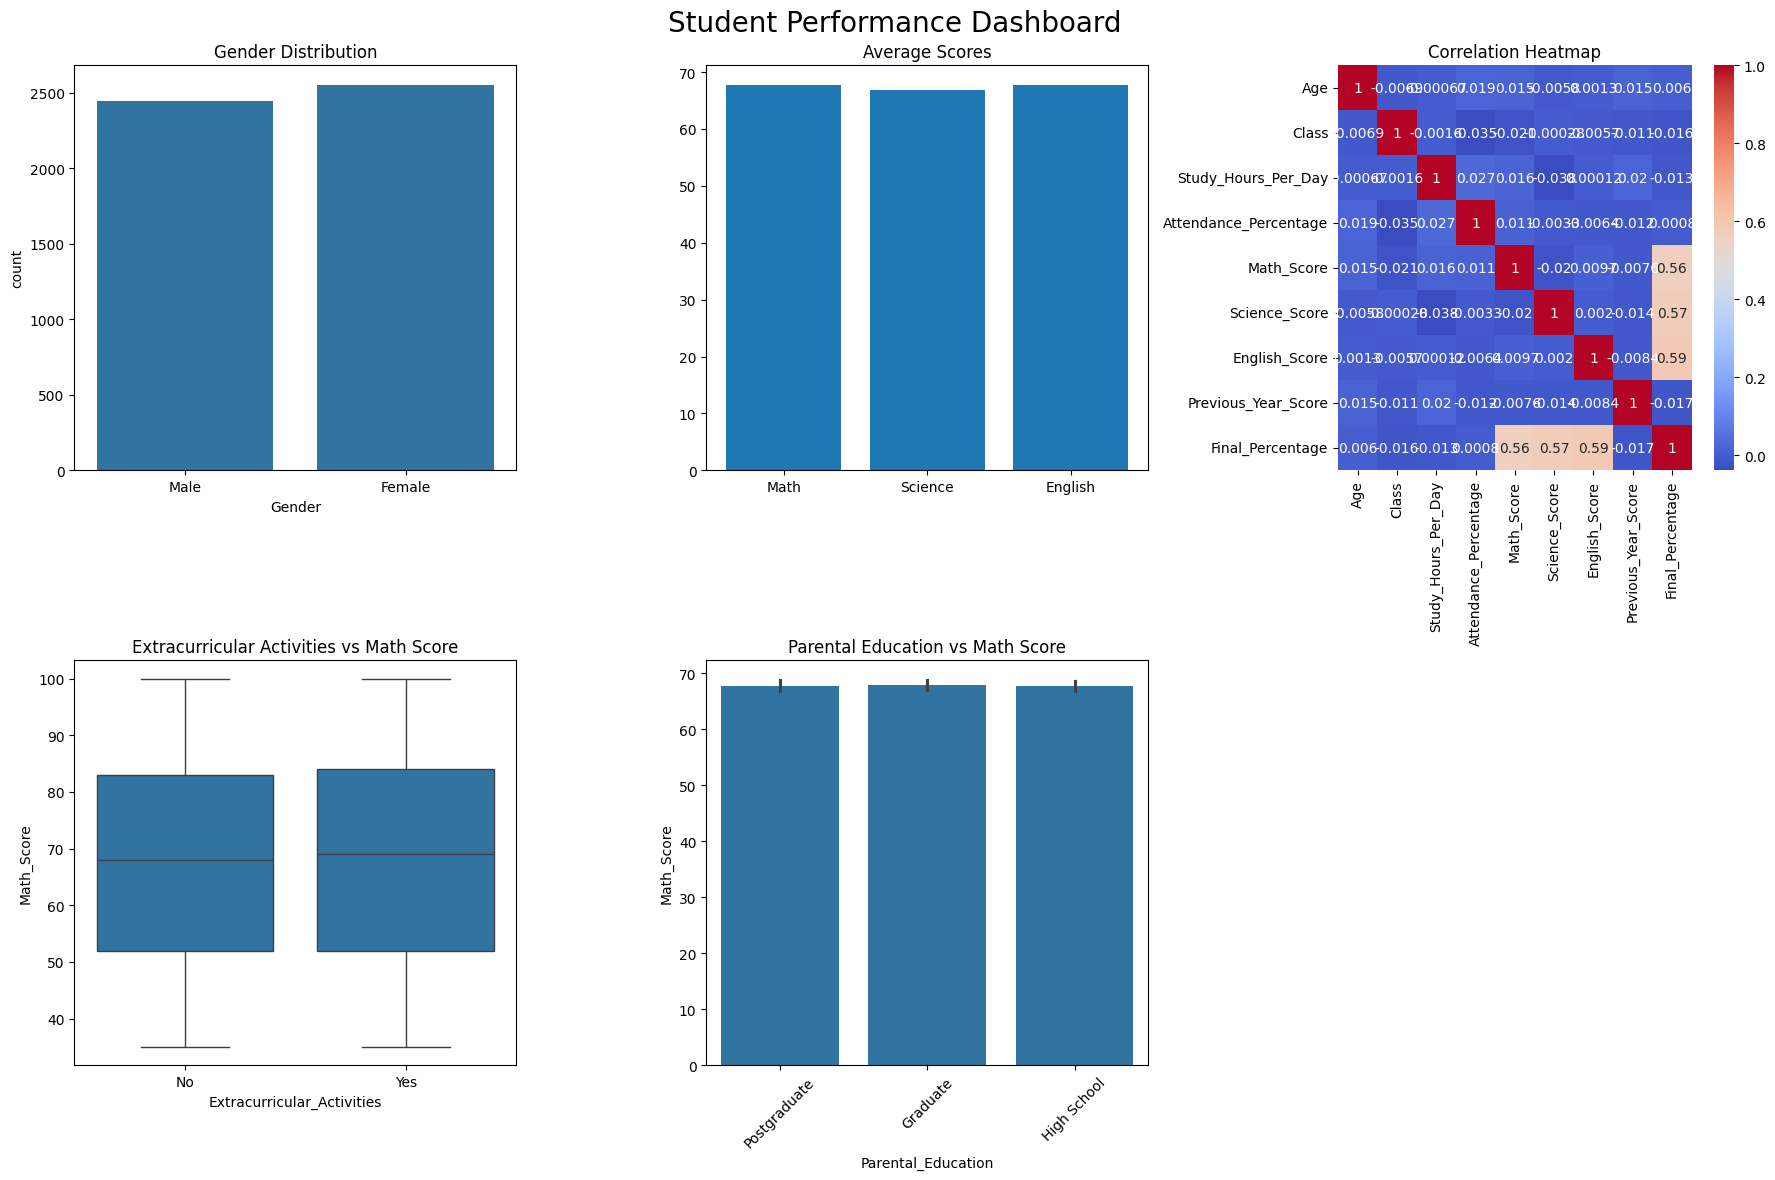

In [24]:
plt.figure(figsize=(18,12))

plt.suptitle(
    "Student Performance Dashboard",
    fontsize=20
)

# Graph 1
plt.subplot(2,3,1)
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")

# Graph 2
plt.subplot(2,3,2)

scores = [
    df['Math_Score'].mean(),
    df['Science_Score'].mean(),
    df['English_Score'].mean()
]

subjects = ['Math', 'Science', 'English']

plt.bar(subjects, scores)
plt.title("Average Scores")

# Graph 3
plt.subplot(2,3,3)

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

# Graph 4
plt.subplot(2,3,4)

sns.boxplot(
    x='Extracurricular_Activities',
    y='Math_Score',
    data=df
)

plt.title("Extracurricular Activities vs Math Score") # Changed title to reflect the used column

# Graph 5
plt.subplot(2,3,5)

sns.barplot(
    x='Parental_Education',
    y='Math_Score',
    data=df
)

plt.xticks(rotation=45)

plt.title("Parental Education vs Math Score") # Changed title to reflect the used column

plt.tight_layout()

plt.show()

**Save Dashboard**

In [25]:
plt.savefig("student_dashboard.png")

<Figure size 640x480 with 0 Axes>

**Export Cleaned Dataset**

In [27]:
df.to_csv("Cleaned_Student_Performance.csv", index=False)

**Download Cleaned Dataset**

In [28]:
from google.colab import files
files.download("Cleaned_Student_Performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion**

This project successfully demonstrated the process of data cleaning, preprocessing, and visualization using the Student Performance dataset. By analyzing factors such as study hours, attendance, parental education, and subject scores, meaningful insights about student performance were identified. The project also helped improve understanding of data analysis, visualization techniques, and storytelling with data using Python libraries like Pandas, Matplotlib, and Seaborn.
